# Paris Weather AI Analyzer

This notebook retrieves Paris weather data from the Open-Meteo API and analyzes a generated weather summary using a Hugging Face sentiment-analysis pipeline.

## Project Objectives

- Call an external REST API
- Process a JSON response
- Create a Pandas DataFrame
- Visualize weather data
- Load a Hugging Face pipeline
- Analyze text generated from API data
- Test the model on 10 additional sentences

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from transformers import pipeline

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Retrieve Paris Weather Data

The Open-Meteo API provides weather information in JSON format.

This request retrieves the maximum and minimum daily temperatures for Paris.

In [4]:
API_URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 48.85,
    "longitude": 2.35,
    "past_days": 7,
    "forecast_days": 1,
    "daily": "temperature_2m_max,temperature_2m_min",
    "timezone": "Europe/Paris",
}

try:
    response = requests.get(
        API_URL,
        params=params,
        timeout=30,
    )

    response.raise_for_status()
    weather_data = response.json()

    print("Weather data retrieved successfully.")

except requests.RequestException as error:
    raise RuntimeError(
        f"Could not retrieve weather data: {error}"
    ) from error

Weather data retrieved successfully.


In [5]:
daily_data = weather_data["daily"]

weather_df = pd.DataFrame(
    {
        "date": daily_data["time"],
        "max_temperature": daily_data["temperature_2m_max"],
        "min_temperature": daily_data["temperature_2m_min"],
    }
)

weather_df["date"] = pd.to_datetime(weather_df["date"])

weather_df

,date,max_temperature,min_temperature
0,2026-07-09,33.5,22.6
1,2026-07-10,35.6,21.9
2,2026-07-11,36.2,22.4
3,2026-07-12,35.7,22.7
4,2026-07-13,34.7,22.6
5,2026-07-14,34.5,21.1
6,2026-07-15,32.0,23.9
7,2026-07-16,33.4,20.8


## 2. Generate Text From the API Data

The numerical API data is converted into a natural-language summary. This text will be sent to the Hugging Face model.

In [6]:
average_max = weather_df["max_temperature"].mean()
average_min = weather_df["min_temperature"].mean()

if average_max >= 30:
    weather_description = "very hot"
elif average_max >= 24:
    weather_description = "warm and pleasant"
elif average_max >= 16:
    weather_description = "mild"
elif average_max >= 8:
    weather_description = "cool"
else:
    weather_description = "very cold"

weather_summary = (
    f"Paris experienced {weather_description} weather during the selected "
    f"period. The average maximum temperature was {average_max:.1f}°C, "
    f"and the average minimum temperature was {average_min:.1f}°C."
)

print(weather_summary)

Paris experienced very hot weather during the selected period. The average maximum temperature was 34.5°C, and the average minimum temperature was 22.2°C.


## 3. Visualize the Weather Data

The chart compares Paris's daily maximum and minimum temperatures.

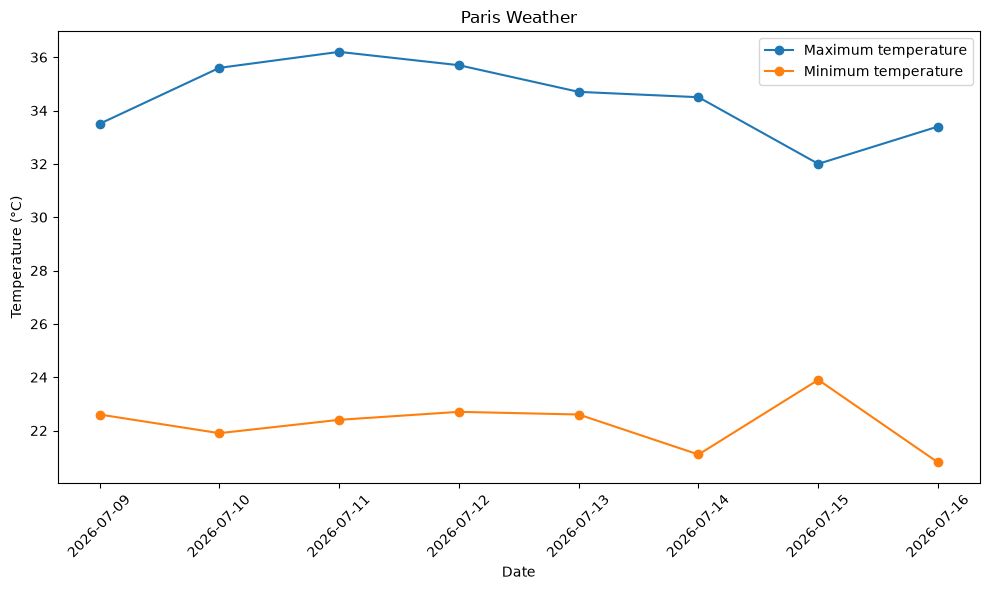

Chart saved to: outputs\paris_weather_chart.png


In [7]:
output_directory = Path("outputs")
output_directory.mkdir(exist_ok=True)

plt.figure(figsize=(10, 6))

plt.plot(
    weather_df["date"],
    weather_df["max_temperature"],
    marker="o",
    label="Maximum temperature",
)

plt.plot(
    weather_df["date"],
    weather_df["min_temperature"],
    marker="o",
    label="Minimum temperature",
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Paris Weather")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

chart_path = output_directory / "paris_weather_chart.png"
plt.savefig(chart_path)
plt.show()

print(f"Chart saved to: {chart_path}")

In [8]:
data_directory = Path("data")
data_directory.mkdir(exist_ok=True)

csv_path = data_directory / "paris_weather.csv"
weather_df.to_csv(csv_path, index=False)

print(f"Weather data saved to: {csv_path}")

Weather data saved to: data\paris_weather.csv


## 4. Load a Hugging Face Pipeline

This section loads a pretrained DistilBERT sentiment-analysis model.

The model classifies English text as either:

- `POSITIVE`
- `NEGATIVE`

In [12]:
MODEL_NAME = (
    "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
)

sentiment_analyzer = pipeline(
    task="sentiment-analysis",
    model=MODEL_NAME,
    device=-1,
)

print("Hugging Face pipeline loaded successfully.")

NameError: name 'torch' is not defined

## 5. Analyze the Weather Summary

The text generated from the Open-Meteo API data is passed to the Hugging Face model.

In [13]:
weather_sentiment = sentiment_analyzer(weather_summary)[0]

sentiment_label = weather_sentiment["label"]
confidence_score = weather_sentiment["score"]

print(f"Weather summary:\n{weather_summary}\n")
print(f"Sentiment: {sentiment_label}")
print(f"Confidence: {confidence_score:.2%}")

NameError: name 'sentiment_analyzer' is not defined